# Deep Q-Network (DQN) with CartPole

In this notebook, we'll implement an agent **that balances a pole on a cart** using a Deep Q-Network.

[CartPole environment documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/)

The goal is to keep the pole upright for as long as possible by pushing the cart left or right. Unlike the tabular Q-learning approach (e.g. FrozenLake), here we use a **neural network to approximate the Q-function** over continuous state observations.

**Your task:** fill in every `?` in the code cells below as we build the agent together in class.


## Step 0: Install and import the dependencies 📚

We use four main libraries:
- `Gymnasium` — the RL environment (successor to OpenAI Gym)
- `PyTorch` — the neural network that approximates Q(s, a)
- `NumPy` — numerical arrays for states and batch training
- `Matplotlib` — plotting learning curves


In [ ]:
# # Install dependencies (quiet output). In Colab, re-run this cell if packages are missing.
# !pip install gymnasium matplotlib "imageio[ffmpeg]" -q  > /dev/null 2>&1


In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random
import matplotlib.pyplot as plt
import imageio
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

%matplotlib inline


## Step 1: Define the DQN agent 🧠

A **Deep Q-Network (DQN)** learns Q(s, a) with a neural network instead of a Q-table.
Key ideas:
- **Experience replay**: store transitions (s, a, r, s', done) and train on random mini-batches to break correlation between consecutive samples.
- **Epsilon-greedy**: explore random actions early, then gradually exploit the learned policy.
- **Bellman target**: Q(s, a) ← r + γ max<sub>a'</sub> Q(s', a') for non-terminal steps.

We implement the network as a `QNetwork` class in **PyTorch** (`nn.Module`) and wrap it inside `DQNAgent`, which handles replay and exploration.

This is a **vanilla DQN** (one network used for both action selection and target computation — no separate target network).


In [4]:
class QNetwork(nn.Module):
    """Feed-forward network: state vector -> Q-value for each action."""

    def __init__(self, state_size, action_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size),  # raw Q-values, no activation
        )

    def forward(self, state):
        return self.network(state)


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        # Experience replay buffer
        self.memory = deque(maxlen=10000) # first in first out

        # Hyperparameters
        self.gamma = 0.99          # discount factor γ
        self.epsilon = 1        # exploration rate (starts fully random)
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.993
        self.learning_rate = 0.001

        self.model = QNetwork(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        """Store one transition in the replay buffer."""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """Epsilon-greedy action selection: explore vs exploit."""
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)  # explore: random action
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            q_values = self.model(state_tensor)
            return q_values.argmax(dim=1).item()  # exploit: highest predicted Q-value

    def replay(self, batch_size):
        """Train the network on a random mini-batch from the replay buffer."""
        minibatch = random.sample(self.memory, batch_size)

        states = torch.FloatTensor(np.squeeze(np.array([i[0] for i in minibatch])))
        actions = torch.LongTensor([i[1] for i in minibatch])
        rewards = torch.FloatTensor([i[2] for i in minibatch])
        next_states = torch.FloatTensor(np.squeeze(np.array([i[3] for i in minibatch])))
        dones = torch.FloatTensor([i[4] for i in minibatch])

        # Q(s, a) for the actions actually taken
        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1) # predicted

        # Bellman target: r + γ max_a' Q(s', a')  (zero future term if done)
        with torch.no_grad():
            next_q = self.model(next_states).max(dim=1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones) # target

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


## Step 2: Create the environment 🎮

Gymnasium provides the CartPole environment. We read the state and action dimensions from:
- `env.observation_space.shape[0]` — length of the state vector (4 floats)
- `env.action_space.n` — number of discrete actions (2)


In [5]:
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)

print(f"State size: {state_size}, Action size: {action_size}")


State size: 4, Action size: 2


## Step 3: Train the agent 🏋️

The training loop follows the standard RL interaction pattern:
1. Observe state → select action → receive reward and next state.
2. Store the transition in the replay buffer.
3. Periodically sample a batch and update the Q-network.

Gymnasium splits episode endings into:
- `terminated` — the pole fell (failure)
- `truncated` — the time limit was reached (success in CartPole-v1)

We apply a **reward shaping** trick: a large negative reward when the episode ends, to strongly penalize dropping the pole.


Episode 1/100 | steps: 87 | epsilon: 1.000 | episode reward: -14.0 | mean reward: -14.0
Episode 2/100 | steps: 11 | epsilon: 1.000 | episode reward: -90.0 | mean reward: -52.0
Episode 3/100 | steps: 26 | epsilon: 0.945 | episode reward: -75.0 | mean reward: -59.7
Episode 4/100 | steps: 11 | epsilon: 0.919 | episode reward: -90.0 | mean reward: -67.2
Episode 5/100 | steps: 22 | epsilon: 0.875 | episode reward: -79.0 | mean reward: -69.6
Episode 6/100 | steps: 24 | epsilon: 0.827 | episode reward: -77.0 | mean reward: -70.8
Episode 7/100 | steps: 15 | epsilon: 0.799 | episode reward: -86.0 | mean reward: -73.0
Episode 8/100 | steps: 13 | epsilon: 0.777 | episode reward: -88.0 | mean reward: -74.9
Episode 9/100 | steps: 19 | epsilon: 0.745 | episode reward: -82.0 | mean reward: -75.7
Episode 10/100 | steps: 27 | epsilon: 0.699 | episode reward: -74.0 | mean reward: -75.5
Episode 11/100 | steps: 35 | epsilon: 0.642 | episode reward: -66.0 | mean reward: -74.6
Episode 12/100 | steps: 15 | e

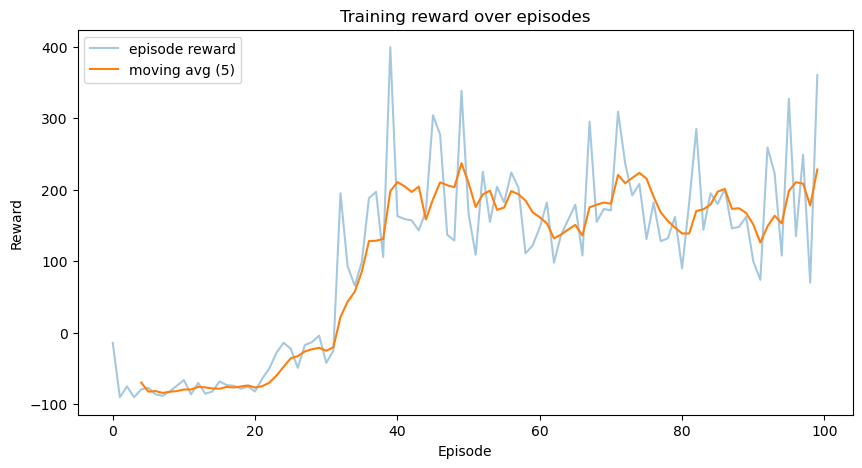

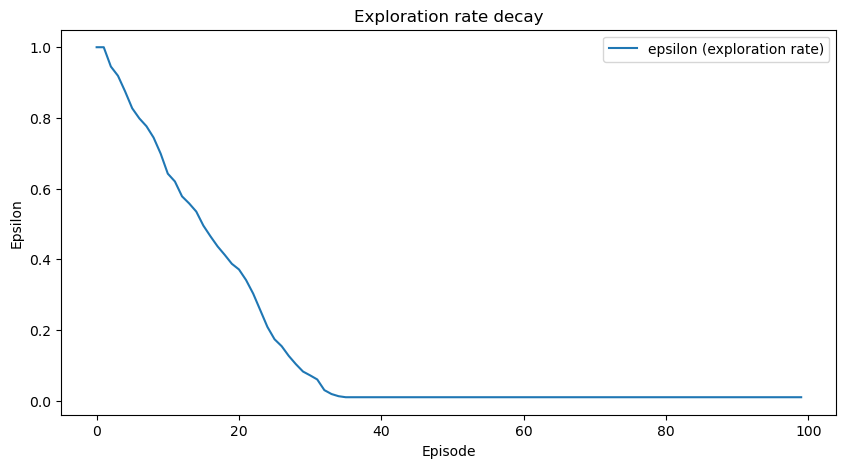

In [6]:
EPISODES = 100
max_steps_per_episode = 500
batch_size = 100
learning_freq = 3  # train every N steps once the buffer is large enough

rewards = []
epsilons = []

for episode in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])
    episode_reward = 0

    for step in range(max_steps_per_episode):
        # choose action
        action = agent.act(state)

        # apply action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # penalise failure strongly so the agent learns to avoid dropping the pole
        reward = reward if not done else -100
        episode_reward += reward

        next_state = np.reshape(next_state, [1, state_size])

        # remember transition
        agent.remember(state, action, reward, next_state, done)
        state = next_state

        if done:
            break

        # replay
        if len(agent.memory) > batch_size and step % learning_freq == 0:
            agent.replay(batch_size)

    rewards.append(episode_reward)
    epsilons.append(agent.epsilon)

    mean_score = sum(rewards) / len(rewards)
    print(
        f"Episode {episode + 1}/{EPISODES} | "
        f"steps: {step + 1} | "
        f"epsilon: {agent.epsilon:.3f} | "
        f"episode reward: {episode_reward:.1f} | "
        f"mean reward: {mean_score:.1f}"
    )

print(f"\nAverage score over {EPISODES} episodes: {sum(rewards) / EPISODES:.1f}")

# Plot raw and smoothed episode rewards
plt.figure(figsize=(10, 5))
averaging_window = 5
smoothed = np.convolve(rewards, np.ones(averaging_window) / averaging_window, mode='valid')
plt.plot(range(EPISODES), rewards, alpha=0.4, label="episode reward")
plt.plot(range(averaging_window - 1, EPISODES), smoothed, label=f"moving avg ({averaging_window})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.title("Training reward over episodes")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(EPISODES), epsilons, label="epsilon (exploration rate)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.title("Exploration rate decay")
plt.show()


## Step 4: Watch the trained agent play CartPole! 👾

After training, we record one episode as a video. The agent acts greedily (`epsilon = 0`) using only the learned policy.

On **Google Colab**, a virtual display is needed because there is no physical screen. Locally, rendering works without it.


In [7]:
# Detect Colab and install system dependencies only when needed
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install pyvirtualdisplay -q
    !apt-get install -y xvfb ffmpeg > /dev/null 2>&1
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(1400, 900))
    display.start()
    print("Virtual display started (Colab).")
else:
    print("Running locally — no virtual display needed.")


Running locally — no virtual display needed.


In [8]:
def embed_video(filename):
    """Display an MP4 file inline in the notebook (works in Jupyter and Colab)."""
    with open(filename, "rb") as video_file:
        encoded = base64.b64encode(video_file.read())
    ipythondisplay.display(HTML(data='''<video alt="CartPole agent" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))


video_name = "cart-pole-test"
play_env = gym.make("CartPole-v1", render_mode="rgb_array")
agent.epsilon = 0  # pure exploitation — no random actions

images = []
state, _ = play_env.reset()
images.append(play_env.render())

total_reward = 0
for step in range(max_steps_per_episode):
    state_input = np.reshape(state, [1, state_size])
    action = agent.act(state_input)
    state, reward, terminated, truncated, _ = play_env.step(action)
    images.append(play_env.render())
    total_reward += reward

    if terminated or truncated:
        outcome = "pole fell" if terminated else "time limit reached (success!)"
        print(f"Episode finished after {step + 1} steps ({outcome}). Total reward: {total_reward:.1f}")
        break

imageio.mimsave(f"./{video_name}.mp4", [np.array(img) for img in images], fps=30)
play_env.close()

embed_video(f"./{video_name}.mp4")


Episode finished after 303 steps (pole fell). Total reward: 303.0


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Step 5: Replay-parameter study 🔬

**Discussion topic:** *play with the replay parameters (memory size, batch size, learning/update frequency, epsilon decay) and see how they affect performance.*

The cell below is **self-contained**: it defines its own parameterised network + training loop (it does **not** reuse the `agent` trained above), runs several replay configurations for the same number of episodes under the same seed, and reports end-of-training metrics plus a learning-curve comparison.

We judge configurations mainly by **Last 20 Strong %** — the fraction of the final 20 episodes that balanced the pole for ≥ 475 steps — because it reflects the *converged* policy, after exploration has decayed. Overall averages are dragged down by the poor early-learning episodes.

**Metrics reported per configuration**

| Column | Meaning |
|---|---|
| Avg Last 20 Length | mean episode length over the final 20 episodes |
| Avg Episode Length | mean episode length over all episodes |
| Strong Success % (≥475) | % of all episodes that lasted ≥ 475 steps |
| Last 20 Strong % | % of the final 20 episodes that lasted ≥ 475 steps |
| Perfect Episode % (=500) | % of episodes that hit the 500-step cap |
| Best Length | longest single episode |
| First Strong Episode | episode number where length first reached ≥ 475 |

> ⚠️ Training every configuration for 1000 episodes is **slow on CPU** (several minutes each — ~10–20 min total). Set `EPISODES_PER_CONFIG` lower (e.g. 300) for a quick run.

> ⚠️ This setup is **replay-only — no target network** (just like the rest of the notebook). Expect noisy curves and seed sensitivity; configs that update too frequently (e.g. *Frequent Learning*, `learning_freq=1`) tend to destabilise and collapse, which is exactly the effect this study makes visible.


In [ ]:
# ======================================================================
# Step 5 — Replay-parameter study  (SELF-CONTAINED)
# Trains a fresh DQN on CartPole under several replay configurations and
# reports end-of-training metrics + a learning-curve comparison.
# Does NOT touch the `agent` / `env` trained earlier in the notebook.
# ======================================================================
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

try:
    import pandas as pd
    _HAVE_PANDAS = True
except ImportError:
    _HAVE_PANDAS = False

# ---- experiment grid (one row per configuration) --------------------
EXPERIMENTS = [
    {"name": "Small Memory",      "memory_size": 1000,  "batch_size": 64,  "learning_freq": 3, "epsilon_decay": 0.995},
    {"name": "Baseline",          "memory_size": 10000, "batch_size": 100, "learning_freq": 3, "epsilon_decay": 0.993},
    {"name": "Recommended",       "memory_size": 20000, "batch_size": 64,  "learning_freq": 4, "epsilon_decay": 0.995},
    {"name": "Frequent Learning", "memory_size": 10000, "batch_size": 64,  "learning_freq": 1, "epsilon_decay": 0.995},
]

EPISODES_PER_CONFIG = 1000   # <-- lower to ~300 for a quick smoke test (1000 is slow on CPU)
MAX_STEPS           = 500     # CartPole-v1 hard cap
STRONG_THRESHOLD    = 475     # an episode is "strong" if the pole survives this long
SEED                = 42      # same seed for every config -> fair comparison


class _StudyQNet(nn.Module):
    """Same 4 -> 128 -> 128 -> 2 architecture as the notebook's QNetwork."""
    def __init__(self, n_state, n_action):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_state, 128), nn.ReLU(),
            nn.Linear(128, 128),     nn.ReLU(),
            nn.Linear(128, n_action),
        )

    def forward(self, x):
        return self.net(x)


def train_one_config(cfg, episodes, seed):
    """Train a fresh DQN under one replay config; return per-episode lengths (steps survived)."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    env = gym.make("CartPole-v1")
    n_state  = env.observation_space.shape[0]
    n_action = env.action_space.n

    model     = _StudyQNet(n_state, n_action)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn   = nn.MSELoss()
    memory    = deque(maxlen=cfg["memory_size"])
    gamma, eps, eps_min = 0.99, 1.0, 0.01

    lengths = []
    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        state = np.asarray(state, dtype=np.float32)

        for step in range(MAX_STEPS):
            # epsilon-greedy action
            if np.random.rand() <= eps:
                action = random.randrange(n_action)
            else:
                with torch.no_grad():
                    action = int(model(torch.from_numpy(state).unsqueeze(0)).argmax(1).item())

            nxt, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            nxt = np.asarray(nxt, dtype=np.float32)
            shaped = reward if not done else -100.0          # same reward shaping as Step 3
            memory.append((state, action, shaped, nxt, float(done)))
            state = nxt

            # learn on a random minibatch (the replay params we are studying)
            if len(memory) > cfg["batch_size"] and step % cfg["learning_freq"] == 0:
                batch = random.sample(memory, cfg["batch_size"])
                s  = torch.from_numpy(np.array([b[0] for b in batch], dtype=np.float32))
                a  = torch.tensor([b[1] for b in batch], dtype=torch.long)
                r  = torch.tensor([b[2] for b in batch], dtype=torch.float32)
                ns = torch.from_numpy(np.array([b[3] for b in batch], dtype=np.float32))
                d  = torch.tensor([b[4] for b in batch], dtype=torch.float32)

                q_pred = model(s).gather(1, a.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    q_next   = model(ns).max(1)[0]
                    q_target = r + gamma * q_next * (1 - d)   # (1-d) zeroes the future term at terminal steps
                loss = loss_fn(q_pred, q_target)
                optimizer.zero_grad(); loss.backward(); optimizer.step()

                if eps > eps_min:                              # epsilon decays per replay (as in Step 3)
                    eps *= cfg["epsilon_decay"]

            if done:
                break

        lengths.append(step + 1)                              # steps the pole stayed up
    env.close()
    return np.array(lengths)


def summarize(name, cfg, lengths):
    last20 = lengths[-20:]
    strong = lengths >= STRONG_THRESHOLD
    return {
        "Experiment":               name,
        "Memory Size":              cfg["memory_size"],
        "Batch Size":               cfg["batch_size"],
        "Learning Freq":            cfg["learning_freq"],
        "Epsilon Decay":            cfg["epsilon_decay"],
        "Avg Last 20 Length":       round(float(last20.mean()), 1),
        "Avg Episode Length":       round(float(lengths.mean()), 1),
        "Strong Success % (>=475)": round(100 * float(strong.mean()), 1),
        "Last 20 Strong %":         round(100 * float((last20 >= STRONG_THRESHOLD).mean()), 1),
        "Perfect Episode % (=500)": round(100 * float((lengths == 500).mean()), 1),
        "Best Length":              int(lengths.max()),
        "First Strong Episode":     int(np.argmax(strong) + 1) if strong.any() else None,
    }


# ---- run every configuration ----------------------------------------
rows, curves = [], {}
for cfg in EXPERIMENTS:
    print(f"Training '{cfg['name']}' for {EPISODES_PER_CONFIG} episodes ...", flush=True)
    lengths = train_one_config(cfg, EPISODES_PER_CONFIG, SEED)
    curves[cfg["name"]] = lengths
    rows.append(summarize(cfg["name"], cfg, lengths))
    print(f"   -> avg last-20 length {rows[-1]['Avg Last 20 Length']}, "
          f"last-20 strong {rows[-1]['Last 20 Strong %']}%", flush=True)

# ---- results table --------------------------------------------------
if _HAVE_PANDAS:
    results = pd.DataFrame(rows)
    try:
        from IPython.display import display
        display(results)
    except Exception:
        print(results.to_string(index=False))
else:
    header = list(rows[0].keys())
    print("\n" + " | ".join(header))
    for row in rows:
        print(" | ".join(str(row[c]) for c in header))

# ---- learning-curve comparison (smoothed) ---------------------------
plt.figure(figsize=(11, 5))
W = 20
for name, lengths in curves.items():
    if len(lengths) >= W:
        smooth = np.convolve(lengths, np.ones(W) / W, mode="valid")
        plt.plot(range(W - 1, len(lengths)), smooth, label=name)
plt.axhline(STRONG_THRESHOLD, ls="--", c="gray", alpha=0.6, label=f"strong ({STRONG_THRESHOLD})")
plt.xlabel("Episode")
plt.ylabel(f"Episode length (moving avg, w={W})")
plt.title("Replay-parameter study — CartPole DQN")
plt.legend()
plt.show()
